In [5]:
import pandas as pd

<h1>Loading datasets</h1>

In [7]:
student_info = pd.read_csv(r"open+university+learning+analytics+dataset/studentInfo.csv")
student_vle = pd.read_csv(r"open+university+learning+analytics+dataset/studentVle.csv")
vle = pd.read_csv(r"open+university+learning+analytics+dataset/vle.csv")

In [8]:
print(student_info.shape)
print(student_vle.shape)

(32593, 12)
(10655280, 6)


<strong>32k students, 10M interactions</strong>

In [9]:
student_info[[
    "id_student",
    "final_result",
    "age_band",
    "gender",
    "highest_education",
    "disability"
]].head()


,id_student,final_result,age_band,gender,highest_education,disability
0,11391,Pass,55<=,M,HE Qualification,N
1,28400,Pass,35-55,F,HE Qualification,N
2,30268,Withdrawn,35-55,F,A Level or Equivalent,Y
3,31604,Pass,35-55,F,A Level or Equivalent,N
4,32885,Pass,0-35,F,Lower Than A Level,N


In [10]:
student_vle[[
    "id_student",
    "id_site",
    "date",
    "sum_click"
]].head()

,id_student,id_site,date,sum_click
0,28400,546652,-10,4
1,28400,546652,-10,1
2,28400,546652,-10,1
3,28400,546614,-10,11
4,28400,546714,-10,1


In [11]:
vle[[
    "id_site",
    "activity_type"
]].head()

,id_site,activity_type
0,546943,resource
1,546712,oucontent
2,546998,resource
3,546888,url
4,547035,resource


<h1>Target Variable</h1>

In [13]:
df = student_info[[
    "id_student",
    "final_result",
    "age_band",
    "gender",
    "highest_education",
    "disability"
]].copy()       #kept only relevant column

In [14]:
student_info["final_result"].value_counts()

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

<h1>Target Definition</h1>

In [16]:
df = df[df["final_result"].isin(["Withdrawn", "Pass", "Distinction"])] #Removed Fail which was ambiguous
df["dropout"] = (df["final_result"] == "Withdrawn").astype(int)
df.drop(columns="final_result", inplace=True)  #Dropped original outcome column
df["dropout"].value_counts(normalize=True) #Verification

dropout
0    0.602365
1    0.397635
Name: proportion, dtype: float64

<h1>Early Prediction Window (Week 4)</h1>

In [18]:
early_vle = student_vle[student_vle["date"] <= 28].copy() #Filtered LMS activity to first 4 weeks
early_vle["date"].max()

28

<h1>LMS Feature Engineering</h1>
<h2>🧠 The features which i need to extract</h2>
From early_vle (Week ≤ 28), for each student:

- total_clicks → overall engagement

- active_days → how many days the student was active

- avg_clicks_per_day → engagement intensity

- unique_activities → diversity of LMS usage

In [20]:
# Merging activity type (needed for diversity)
early_vle = early_vle.merge(
    vle[["id_site", "activity_type"]],
    on="id_site",
    how="left"
)

# Aggregating LMS behavior per student
lms_features = (
    early_vle
    .groupby("id_student")
    .agg(
        total_clicks=("sum_click", "sum"),
        active_days=("date", "nunique"),
        unique_activities=("activity_type", "nunique")
    )
    .reset_index()
)

#Average clicks per active day
lms_features["avg_clicks_per_day"] = (
    lms_features["total_clicks"] / lms_features["active_days"]
)

<h1>MERGING FEATURES + CLEANING DATA</h1>

- Merging behavioral (LMS) features with demographic + target

- Handling students with no LMS activity

- Preparing a single ML-ready table

<strong>Some students may have zero LMS activity in the first 4 weeks.</strong>

📌 That itself is a strong dropout signal, so:

- I keep those students

- Fill LMS features with 0, not drop them

In [22]:
data = df.merge(lms_features, on="id_student", how="left")

lms_cols = [
    "total_clicks", "active_days",
    "unique_activities", "avg_clicks_per_day"
]
data[lms_cols] = data[lms_cols].fillna(0)
data.isnull().sum()

id_student            0
age_band              0
gender                0
highest_education     0
disability            0
dropout               0
total_clicks          0
active_days           0
unique_activities     0
avg_clicks_per_day    0
dtype: int64

In [23]:
data["dropout"].value_counts()

dropout
0    15385
1    10156
Name: count, dtype: int64

<h1>ENCODING CATEGORICAL VARIABLES + + TRAIN–TEST SPLIT</h1>

- Converting categorical variables into numeric form
- Create a clean train–test split

In [25]:
# Separating features and target
X = data.drop(columns=["id_student", "dropout"])
y = data["dropout"]

#One-hot encoding categorical variables as categories have no ordinal meaning & works perfectly with Logistic Regression, RF, XGBoost
X = pd.get_dummies(
    X,
    columns=["age_band", "gender", "highest_education", "disability"],
    drop_first=True #avoids multicollinearity
)

# Cleaning column names for XGBoost
X.columns = (
    X.columns
    .str.replace("<", "lt", regex=False)
    .str.replace(">", "gt", regex=False)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace(" ", "_", regex=False)
)

# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y #ensures dropout ratio stays consistent
)

y_train.value_counts()
y_test.value_counts()

dropout
0    3077
1    2032
Name: count, dtype: int64

<h1>TRAIN BASELINE MODEL (LOGISTIC REGRESSION)</h1>

- Establishing a baseline

- Evaluate with proper metrics

- Set a reference for advanced models

📌 We are not trying to “win” here — just to set a benchmark.
<h2>🧠 Why Logistic Regression</h2>

>Logistic Regression provides an interpretable baseline for binary classification and allows comparison with more complex models.

In [26]:
#Training Logistic Regression
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced", #handles class imbalance cleanly
    random_state=42
)

log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
#Made predictions
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]
print(y_pred_lr)
print(y_prob_lr)

[0 0 0 ... 0 1 1]
[0.38824056 0.12225888 0.21955905 ... 0.2335211  0.67819122 0.83881344]


In [28]:
#Evaluating model
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

              precision    recall  f1-score   support

           0       0.75      0.72      0.73      3077
           1       0.60      0.63      0.61      2032

    accuracy                           0.68      5109
   macro avg       0.67      0.67      0.67      5109
weighted avg       0.69      0.68      0.69      5109

ROC-AUC: 0.7309122451564696


> Logistic Regression was used as a baseline model with class weighting to handle imbalance. Performance was evaluated using recall, F1-score, and ROC-AUC.

<h1>TRAINING RANDOM FOREST (NON-LINEAR MODEL)</h1>

- Capture non-linear relationships

- Compare against Logistic Regression

<h2>🧠 Why Random Forest</h2>

> Random Forest captures non-linear interactions between demographic and behavioral features and serves as a strong classical ensemble baseline.

In [31]:
#Training Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
#Made Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
print(y_pred_rf)
print(y_prob_rf)

[0 0 0 ... 0 0 1]
[0.27303787 0.29983659 0.45617313 ... 0.27206688 0.36158774 0.95270187]


In [33]:
#Evaluating Model
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.74      0.85      0.79      3077
           1       0.70      0.54      0.61      2032

    accuracy                           0.73      5109
   macro avg       0.72      0.69      0.70      5109
weighted avg       0.72      0.73      0.72      5109

ROC-AUC: 0.7610460452071375


<strong>Compared to Logistic Regression:</strong>

- Higher precision & ROC-AUC
 
- Lower Recall
  
- Comparable F1-score
> Random Forest improves performance by modeling non-linear interactions between early engagement patterns and student demographics.

<h1>TRAINING XGBOOST (⭐FINAL OPTIMIZED MODEL)</h1>

- Training the best-performing model

- Handling class imbalance properly

<h2>🧠 Why XGBoost</h2>

> XGBoost is a gradient boosting model well-suited for tabular data and is effective at capturing complex feature interactions while handling class imbalance.

In [35]:
#!pip install xgboost
from xgboost import XGBClassifier

In [36]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1] #Handles Dropout Imbalance

xgb = XGBClassifier(
    n_estimators=250,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [37]:
# Making Predictions
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
print(y_pred_xgb)
print(y_prob_xgb)

[0 0 1 ... 0 0 1]
[0.22896217 0.3823998  0.5343928  ... 0.27695212 0.37031758 0.9560566 ]


In [38]:
# Evaluating Model
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78      3077
           1       0.68      0.58      0.62      2032

    accuracy                           0.72      5109
   macro avg       0.71      0.70      0.70      5109
weighted avg       0.72      0.72      0.72      5109

ROC-AUC: 0.7614784347418873


<strong>Compared to:</strong>

- Logistic Regression → ❌ weaker overall balance

- Random Forest → ❌ more conservative (lower recall)

<strong>XGBoost show:</strong>

- ✔ Best F1-score (most balanced performance)

- ✔ Highest ROC-AUC (best class discrimination)

- ✔ Balanced recall (higher than Random Forest, lower than Logistic Regression)

📌 Even a small improvement in F1-score and ROC-AUC is significant for early dropout prediction.

## 🏆 Final Model Ranking

### 🥇 1st — **XGBoost (Best Overall)** ⭐

**Why:**
- ✅ Highest **F1-score**, indicating the best balance between precision and recall  
- ✅ Highest **ROC-AUC**, demonstrating superior class discrimination  
- ✅ Balanced prediction behavior (neither overly aggressive nor overly conservative)

📌 *Best suited for early-warning dropout prediction systems.*

---

### 🥈 2nd — **Logistic Regression**

**Why:**
- ✅ Highest **recall**, successfully identifying the largest proportion of dropout cases  
- ❌ Lower precision, leading to more false positives  
- ❌ Lower ROC-AUC compared to tree-based models  

📌 *A strong baseline model with recall-focused behavior but weaker overall balance.*

---

### 🥉 3rd — **Random Forest**

**Why:**
- ✅ Highest **precision**, indicating confident dropout predictions  
- ❌ Lowest recall, missing a significant number of actual dropouts  
- ❌ F1-score comparable to Logistic Regression but with more conservative predictions  

📌 *Too conservative for effective early intervention.*

---

## 📊 Ranking Summary

| Rank | Model | Strength | Weakness |
|------|------|----------|----------|
| 🥇 1 | **XGBoost** | Best F1-score & ROC-AUC | Slightly lower recall than Logistic Regression |
| 🥈 2 | Logistic Regression | Highest recall | Lower precision & ROC-AUC |
| 🥉 3 | Random Forest | Highest precision | Lowest recall |

---

### 🎓 Final Conclusion

> *XGBoost was selected as the final model due to its superior balance between precision and recall, as reflected by the highest F1-score and ROC-AUC, making it the most reliable model for early dropout prediction.*


In [39]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results

,Model,ROC_AUC
0,Logistic Regression,0.730912
1,Random Forest,0.761046
2,XGBoost,0.761478


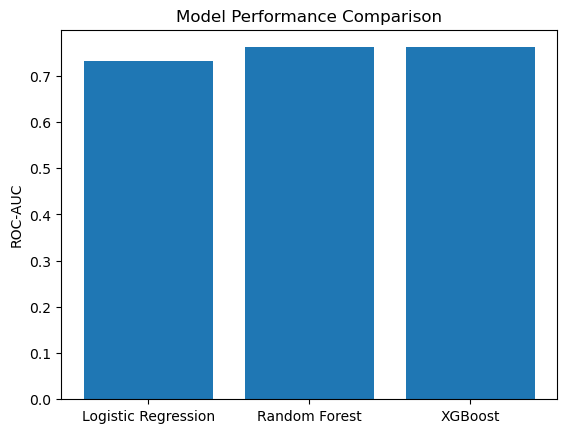

In [40]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results["Model"], results["ROC_AUC"])
plt.ylabel("ROC-AUC")
plt.title("Model Performance Comparison")
plt.show()

In [42]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def evaluate(y_true, y_pred, y_prob):
    return {
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

results = {
    "Logistic Regression": evaluate(y_test, y_pred_lr, y_prob_lr),
    "Random Forest": evaluate(y_test, y_pred_rf, y_prob_rf),
    "XGBoost": evaluate(y_test, y_pred_xgb, y_prob_xgb)
}

results_df = pd.DataFrame(results).T
results_df

,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.598218,0.627953,0.612725,0.730912
Random Forest,0.701464,0.542323,0.611712,0.761046
XGBoost,0.676032,0.580217,0.624470,0.761478


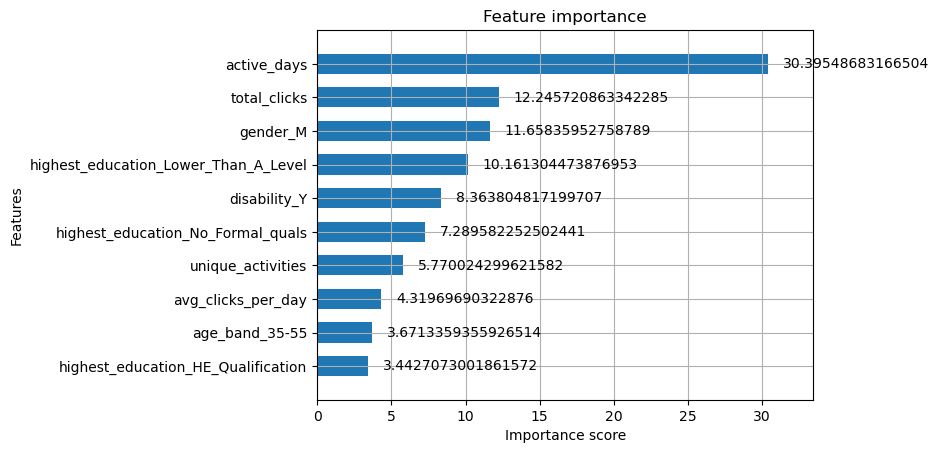

In [43]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(
    xgb,
    importance_type="gain",
    max_num_features=10,
    height=0.6
)
plt.show()